In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Load FM Recorded I/Q

In [4]:
sample_rate_hz: float = 1.024e6 / 5.0
print(f"Sample Rate: {sample_rate_hz/1e3} kHz")

Sample Rate: 204.8 kHz


In [8]:
root = Path("data/fm-iq/")
names_to_signals = {}
for fil in root.glob("*/*.npy"):
    name = fil.parent.stem
    if name not in names_to_signals:
        names_to_signals[name] = []
    
    signal = np.load(fil)
    signal.astype(np.complex64)
    names_to_signals[name].append(signal)
    duration = signal.size / sample_rate_hz
    print(f"Duration: {duration:.01f} sec.")

Duration: 30.0 sec.
Duration: 30.0 sec.
Duration: 30.0 sec.
Duration: 30.0 sec.
Duration: 30.0 sec.
Duration: 60.0 sec.
Duration: 60.0 sec.
Duration: 60.0 sec.
Duration: 30.0 sec.
Duration: 60.0 sec.
Duration: 60.0 sec.


### Plot I/Q

In [9]:
num_plot_samples: int = 1_000_000

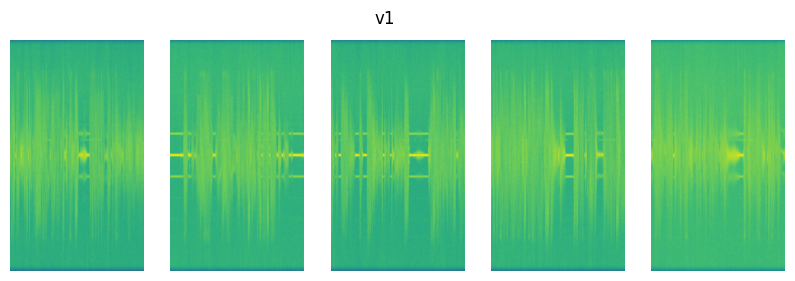

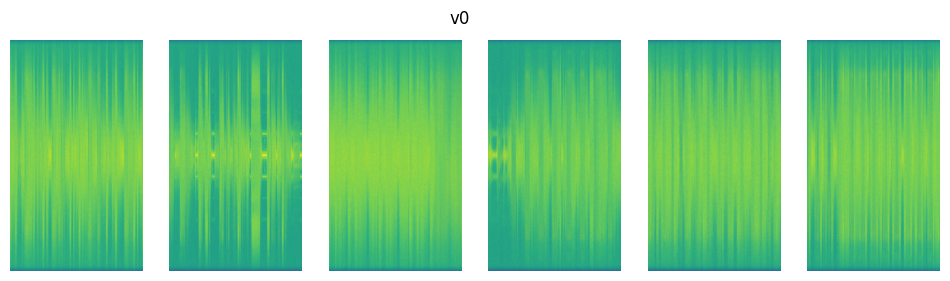

In [12]:
for name, signals in names_to_signals.items():
    num_signals = len(signals)
    fig, axes = plt.subplots(nrows=1, ncols=num_signals)
    fig.set_size_inches(w=num_signals * 2.0, h=3.0)
    
    for sidx, signal in enumerate(signals):
        ax = axes[sidx]
        _ = ax.specgram(
            signal[:num_plot_samples], Fs=sample_rate_hz
        )
        ax.axis("off")
    fig.suptitle(name)

### Demodulate FM

In [15]:
from scipy.signal import resample_poly, firwin

In [16]:
import soundfile as sf

In [17]:
audio_sample_rate_hz: float = 44.1e3

In [18]:
def demodulate_fm(
    signal: np.ndarray, 
    sample_rate_hz: float,
    audio_sample_rate_hz: float,
) -> np.ndarray:
    phase = np.unwrap(np.angle(signal))
    freq = np.diff(phase)
    
    h = firwin(512, audio_sample_rate_hz / sample_rate_hz)
    filter_freq = np.convolve(freq, h, mode="same")
    
    freq_downsampled = resample_poly(filter_freq, audio_sample_rate_hz, sample_rate_hz)
    freq_downsampled /= np.abs(freq_downsampled).max()
    
    return freq_downsampled.astype(np.float32)

In [19]:
names_to_demod = {name: [] for name in names_to_signals.keys()}
for name, signals in names_to_signals.items():
    names_to_demod[name].extend(
        [demodulate_fm(signal, sample_rate_hz, audio_sample_rate_hz) for signal in signals]
    )

In [20]:
for name, demod_signals in names_to_demod.items():
    for sidx, demod_signal in enumerate(demod_signals):
        sf.write(
            f"{name}-{sidx}.wav", 
            demod_signal, 
            int(audio_sample_rate_hz)
        )

### Plot FM Demodulated Audio

In [29]:
dynamic_range_db: float = -70.0
num_plot_samples: int = 100_000

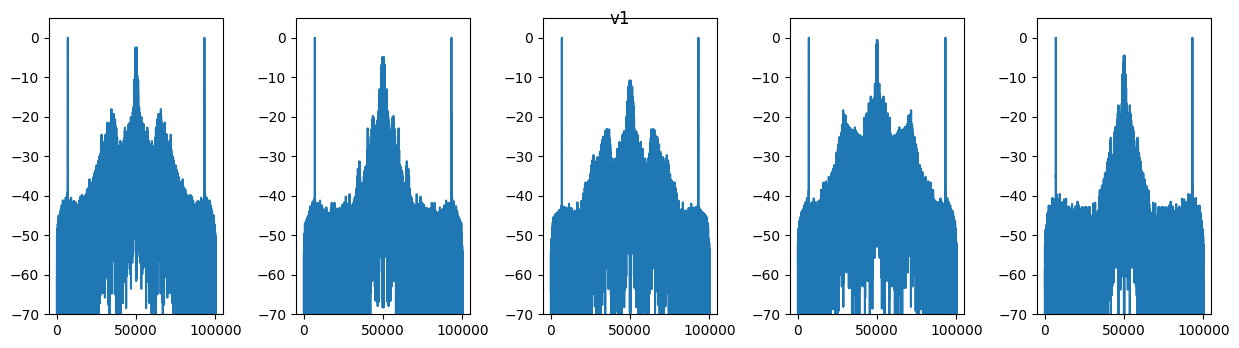

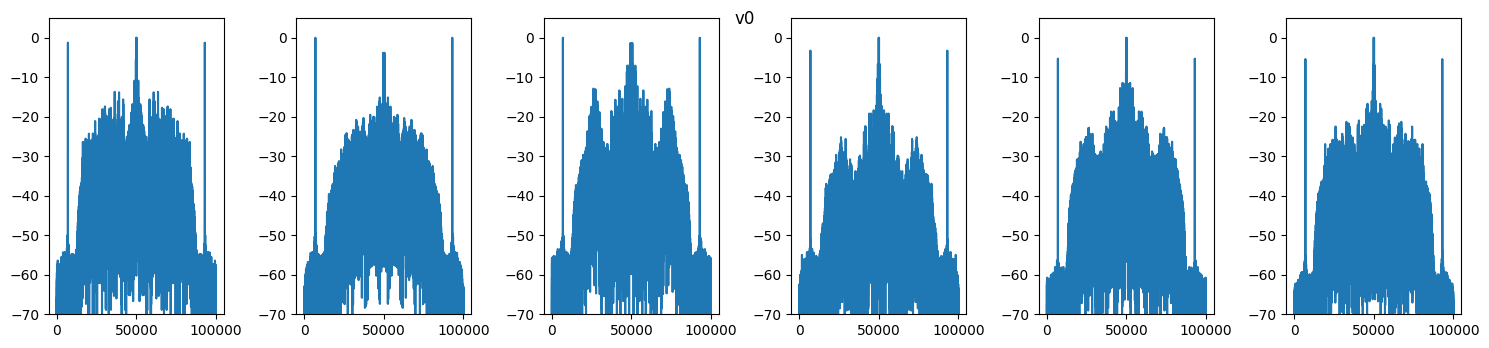

In [30]:
for name, demod_signals in names_to_demod.items():
    num_signals = len(demod_signals)
    fig, axes = plt.subplots(nrows=1, ncols=num_signals)
    fig.set_size_inches(w=num_signals * 2.5, h=3.5)
    
    for sidx, signal in enumerate(demod_signals):
        ax = axes[sidx]
        sxx = np.fft.fftshift(np.fft.fft(signal[:num_plot_samples]))
        sxx_power = np.abs(sxx) ** 2.0
        sxx_power_db = 10.0 * np.log10(sxx_power)
        sxx_power_db -= sxx_power_db.max()
        
        _ = ax.plot(sxx_power_db)
        ax.set_ylim([dynamic_range_db, 0.0 + 5.0])
        
    fig.tight_layout()
    fig.suptitle(name)